# Mogi-Source Stress Analysis — 2015 Axial Eruption Onset

Relates observed shear-wave splitting fast directions at **AXAS1** and **AXEC2** to the
stress change predicted by deflating Mogi sources at the onset of the 2015 eruption.

**Source geometry** (local km, origin at −130.1°, 45.9°):

| Location | x (km E) | y (km N) |
|---|---|---|
| AXAS1 | 7.80 | 3.74 |
| AXEC2 | 9.77 | 4.42 |
| Midpoint(AXAS1, AXEC2) | 8.79 | 4.08 |
| **Source 1** — NW of midpoint | **7.80** | **5.20** |
| **Source 2** — NE of S1, NW of AXEC2 | **9.00** | **5.50** |
| AXCC1 caldera centre (reference) | 7.05 | 6.09 |

**Approach (following Baillard):**
1. Analytically compute surface displacement from two Mogi (point-pressure) sources.
2. Compute the horizontal strain tensor from analytical displacement gradients.
3. Convert strain → stress via `strain2stress` (Baillard, `ARTICLE_deformation_util.py`).
4. Extract the compression axis (SHmax proxy) at each station via eigendecomposition.
5. Compare predicted φ with observed SWS fast directions from our MLDD results.

**Physical parameters:** ν = 0.25, Vs = 3.5 km/s, ρ = 2700 kg/m³ → μ ≈ 33 GPa

**Constraint:** combined vertical subsidence at AXCC1 = **4 m** (eruption onset).
Sign convention: ΔV < 0 = deflation, uz < 0 = subsidence.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import least_squares
from obspy import UTCDateTime

# ── Physical constants ────────────────────────────────────────────────────
nu   = 0.25                          # Poisson's ratio (Baillard)
Vs   = 3.5e3                         # S-wave velocity  [m/s]
rho  = 2700.0                        # Density          [kg/m³]
mu   = rho * Vs**2                   # Shear modulus    [Pa]  ≈ 33 GPa
lam  = (2 * nu * mu) / (1 - 2*nu)   # Lamé λ           [Pa]  = μ for ν=0.25

print(f"μ  = {mu/1e9:.3f} GPa")
print(f"λ  = {lam/1e9:.3f} GPa  (should equal μ for ν=0.25)")

# ── Coordinate system (Baillard's projection origin) ─────────────────────
LON0, LAT0 = -130.1, 45.9   # km origin

def ll2xy(lon, lat):
    """Flat-Earth projection to local km (East = x, North = y)."""
    lat_ref = np.deg2rad((lat + LAT0) / 2)
    x = (lon - LON0) * np.cos(lat_ref) * 111.32
    y = (lat - LAT0) * 111.32
    return x, y

# ── Station and reference locations ──────────────────────────────────────
sta_info = {
    'AXAS1': {'lon': -129.999289, 'lat': 45.93356},
    'AXEC2': {'lon': -129.9738,   'lat': 45.93967},
    'AXCC1': {'lon': -130.0089,   'lat': 45.95468},   # caldera centre (reference)
}
for s, info in sta_info.items():
    x, y = ll2xy(info['lon'], info['lat'])
    info['x_km'], info['y_km'] = x, y
    print(f"{s}: x={x:.2f} km, y={y:.2f} km")

μ  = 33.075 GPa
λ  = 33.075 GPa  (should equal μ for ν=0.25)
AXAS1: x=7.80 km, y=3.74 km
AXEC2: x=9.77 km, y=4.42 km
AXCC1: x=7.05 km, y=6.09 km


In [2]:
# ── Mogi source parameters ────────────────────────────────────────────────
#
# Geometry check (local km from origin -130.1°, 45.9°):
#   AXAS1:                   x= 7.80, y=3.74
#   AXEC2:                   x= 9.77, y=4.42
#   midpoint(AXAS1, AXEC2):  x= 8.79, y=4.08
#   Source 1 NW of mid:      x= 7.80, y=5.20  ← west and north of midpoint
#   Source 2 NE of S1,       x= 9.00, y=5.50  ← east+north of S1, west+north of AXEC2
#          NW of AXEC2
#   AXCC1 (reference only):  x= 7.05, y=6.09
#
# Both sources at 3 km depth. Adjust lon/lat to explore sensitivity.

DEPTH_M = 3000.0   # source depth [m]
DV_FRAC = 0.55     # fraction of total ΔV assigned to Source 1

# Source 1: NW of midpoint(AXAS1, AXEC2)  →  x≈7.80, y≈5.20 km
X1_LON, X1_LAT = -129.9993, 45.9467
X1_KM, Y1_KM   = ll2xy(X1_LON, X1_LAT)

# Source 2: NE of Source 1, NW of AXEC2  →  x≈9.00, y≈5.50 km
X2_LON, X2_LAT = -129.9838, 45.9494
X2_KM, Y2_KM   = ll2xy(X2_LON, X2_LAT)

mid_x = (sta_info['AXAS1']['x_km'] + sta_info['AXEC2']['x_km']) / 2
mid_y = (sta_info['AXAS1']['y_km'] + sta_info['AXEC2']['y_km']) / 2

print(f'Midpoint(AXAS1, AXEC2): ({mid_x:.2f}, {mid_y:.2f}) km')
print(f'Source 1:               ({X1_KM:.2f}, {Y1_KM:.2f}) km')
print(f'Source 2:               ({X2_KM:.2f}, {Y2_KM:.2f}) km')
print(f'AXCC1 (ref):            ({sta_info["AXCC1"]["x_km"]:.2f}, {sta_info["AXCC1"]["y_km"]:.2f}) km')
print()
print(f'S1 NW of midpoint?  W={X1_KM<mid_x},  N={Y1_KM>mid_y}')
print(f'S2 NE of S1?        E={X2_KM>X1_KM},  N={Y2_KM>Y1_KM}')
print(f'S2 NW of AXEC2?     W={X2_KM<sta_info["AXEC2"]["x_km"]},  N={Y2_KM>sta_info["AXEC2"]["y_km"]}')

Midpoint(AXAS1, AXEC2): (8.79, 4.08) km
Source 1:               (7.80, 5.20) km
Source 2:               (9.00, 5.50) km
AXCC1 (ref):            (7.05, 6.09) km

S1 NW of midpoint?  W=True,  N=True
S2 NE of S1?        E=True,  N=True
S2 NW of AXEC2?     W=True,  N=True


In [3]:
# ── Analytical Mogi displacement and strain functions ─────────────────────
#
# Reference: Mogi (1958). All coordinates in METRES.
# For a point-pressure source at (x0, y0) at depth d with volume change dV:
#
#   C  = dV (1−ν) / π
#   r³ = [(x−x0)² + (y−y0)² + d²]^(3/2)
#
#   uz = C · d / r³              (vertical; +ve = uplift)
#   ux = −C · (x−x0) / r³       (East)
#   uy = −C · (y−y0) / r³       (North)

def mogi_uz(x, y, x0, y0, d, dV, nu=0.25):
    """Vertical surface displacement from a single Mogi source. All in metres."""
    C  = dV * (1 - nu) / np.pi
    r3 = ((x - x0)**2 + (y - y0)**2 + d**2)**1.5
    return C * d / r3

def mogi_ux(x, y, x0, y0, d, dV, nu=0.25):
    """East surface displacement."""
    C  = dV * (1 - nu) / np.pi
    r3 = ((x - x0)**2 + (y - y0)**2 + d**2)**1.5
    return -C * (x - x0) / r3

def mogi_uy(x, y, x0, y0, d, dV, nu=0.25):
    """North surface displacement."""
    C  = dV * (1 - nu) / np.pi
    r3 = ((x - x0)**2 + (y - y0)**2 + d**2)**1.5
    return -C * (y - y0) / r3

def mogi_strain_2d(x, y, x0, y0, d, dV, nu=0.25):
    """
    Analytical 2D horizontal strain tensor at surface point (x, y)
    from a Mogi source at (x0, y0, −d). All in metres.

    Returns 2×2 symmetric strain tensor [[e11, e12], [e12, e22]]
    where 1=East, 2=North.

    Derived by differentiating the Mogi displacement field:
      e11 = ∂ux/∂x = −C · r5⁻¹ · [(y−y0)² + d² − 2(x−x0)²]
      e22 = ∂uy/∂y = −C · r5⁻¹ · [(x−x0)² + d² − 2(y−y0)²]
      e12 = ½(∂ux/∂y + ∂uy/∂x) = 3C · (x−x0)(y−y0) · r5⁻¹
    """
    C   = dV * (1 - nu) / np.pi
    dx  = x - x0
    dy  = y - y0
    r2  = dx**2 + dy**2 + d**2
    r5  = r2**2.5

    e11 = -C * (dy**2 + d**2 - 2*dx**2) / r5
    e22 = -C * (dx**2 + d**2 - 2*dy**2) / r5
    e12 =  3 * C * dx * dy / r5

    return np.array([[e11, e12], [e12, e22]])

# ── Baillard's strain2stress and eig_sort (verbatim) ─────────────────────
def strain2stress(strain, poisson, mu_el):
    """Isotropic linear elasticity. From ARTICLE_deformation_util.py (Baillard)."""
    lambda_el = (2 * poisson * mu_el) / (1 - 2 * poisson)
    return lambda_el * strain.trace() * np.eye(2) + 2 * mu_el * strain

def eig_sort(matrix):
    """Eigenvalues sorted descending. From ARTICLE_deformation_util.py (Baillard)."""
    vals, vecs = np.linalg.eig(matrix)
    idx  = np.argsort(-vals)
    return vals[idx], vecs[:, idx]

def shmax_azimuth_deg(stress_tensor):
    """
    Maximum compressive (minimum principal) horizontal stress direction,
    following Baillard's convention (eigvecs[:,1] = compression axis).

    Returns azimuth in degrees CW from North, range [0, 180).
    """
    eigvals, eigvecs = eig_sort(stress_tensor)
    # eigvecs[:,1] = direction of smallest (most compressive) eigenvalue
    vx, vy = eigvecs[0, 1], eigvecs[1, 1]   # East, North components
    az_rad  = np.arctan2(vx, vy)             # CW from North
    az_deg  = np.rad2deg(az_rad) % 180       # fold to [0, 180) axial
    return az_deg, eigvals

print("Mogi and elasticity functions defined.")

Mogi and elasticity functions defined.


In [4]:
# ── Constrain total ΔV from 4 m subsidence at caldera centre ─────────────
#
# Combined vertical displacement at AXCC1 from both sources = −4.0 m.
# DV_FRAC controls the split.  We solve analytically:
#
#   G1 · dV1 + G2 · dV2 = −4.0
#   dV1 = DV_FRAC · dV_total,  dV2 = (1−DV_FRAC) · dV_total

SUBSIDENCE_M = -4.0   # ← change here if using a different constraint (e.g. −2.45)

# Convert source positions to metres
x_cc1, y_cc1 = sta_info['AXCC1']['x_km'] * 1e3, sta_info['AXCC1']['y_km'] * 1e3
x1, y1       = X1_KM * 1e3, Y1_KM * 1e3
x2, y2       = X2_KM * 1e3, Y2_KM * 1e3

# Green's functions at AXCC1 for a unit volume change at each source
G1 = mogi_uz(x_cc1, y_cc1, x1, y1, DEPTH_M, dV=1.0, nu=nu)
G2 = mogi_uz(x_cc1, y_cc1, x2, y2, DEPTH_M, dV=1.0, nu=nu)

# Solve for total dV (split by DV_FRAC)
dV_total = SUBSIDENCE_M / (DV_FRAC * G1 + (1 - DV_FRAC) * G2)
dV1      = DV_FRAC       * dV_total   # m³  (negative = deflation)
dV2      = (1-DV_FRAC)   * dV_total

# Verify
uz_check = mogi_uz(x_cc1, y_cc1, x1, y1, DEPTH_M, dV1, nu) + \
           mogi_uz(x_cc1, y_cc1, x2, y2, DEPTH_M, dV2, nu)

print(f"ΔV total : {dV_total/1e6:.3f} km³  (negative = deflation)")
print(f"ΔV src 1 : {dV1/1e6:.3f} km³")
print(f"ΔV src 2 : {dV2/1e6:.3f} km³")
print(f"uz check at AXCC1: {uz_check:.3f} m  (should equal {SUBSIDENCE_M} m)")

ΔV total : -214.809 km³  (negative = deflation)
ΔV src 1 : -118.145 km³
ΔV src 2 : -96.664 km³
uz check at AXCC1: -4.000 m  (should equal -4.0 m)


In [5]:
# ── Compute stress at AXAS1 and AXEC2 ────────────────────────────────────
#
# Superpose strain tensors from both sources, then convert to stress.
# Stress units = Pa (with physical μ).  Convert to MPa for display.

results = {}

for sta in ['AXAS1', 'AXEC2']:
    xs = sta_info[sta]['x_km'] * 1e3   # m
    ys = sta_info[sta]['y_km'] * 1e3

    # Strain from each source (additive)
    eps1 = mogi_strain_2d(xs, ys, x1, y1, DEPTH_M, dV1, nu)
    eps2 = mogi_strain_2d(xs, ys, x2, y2, DEPTH_M, dV2, nu)
    eps  = eps1 + eps2

    # Stress via Baillard's strain2stress (returns Pa)
    stress = strain2stress(eps, nu, mu)

    # Principal stresses and compression axis direction
    phi_pred_CW_N, eigvals = shmax_azimuth_deg(stress)

    # Predicted uz (vertical displacement, m)
    uz = mogi_uz(xs, ys, x1, y1, DEPTH_M, dV1, nu) + \
         mogi_uz(xs, ys, x2, y2, DEPTH_M, dV2, nu)

    results[sta] = {
        'eps':             eps,
        'stress':          stress,          # Pa
        'eigvals_MPa':     eigvals / 1e6,   # MPa
        'D_MPa':           (eigvals[0] - eigvals[1]) / 1e6,  # differential stress change
        'phi_pred_CW_N':   phi_pred_CW_N,  # degrees CW from North [0,180)
        'uz_m':            uz,
    }

    print(f"\n{'='*55}")
    print(f"  {sta}")
    print(f"{'='*55}")
    print(f"  Vertical displacement:  {uz*100:.1f} cm")
    print(f"  Strain tensor:")
    print(f"    e_EE = {eps[0,0]:.3e}  e_EN = {eps[0,1]:.3e}")
    print(f"    e_NE = {eps[1,0]:.3e}  e_NN = {eps[1,1]:.3e}")
    print(f"  Stress tensor (MPa):")
    s = stress / 1e6
    print(f"    σ_EE = {s[0,0]:+.4f}  σ_EN = {s[0,1]:+.4f}")
    print(f"    σ_NE = {s[1,0]:+.4f}  σ_NN = {s[1,1]:+.4f}")
    print(f"  Principal stresses:  σ1={eigvals[0]/1e6:+.4f} MPa,  σ2={eigvals[1]/1e6:+.4f} MPa")
    print(f"  Differential stress change ΔD = {results[sta]['D_MPa']:+.4f} MPa")
    print(f"  Predicted SHmax (compression axis): {phi_pred_CW_N:.1f}° CW from N")


  AXAS1
  Vertical displacement:  -366.5 cm
  Strain tensor:
    e_EE = 1.074e-03  e_EN = -2.161e-04
    e_NE = -2.161e-04  e_NN = 4.656e-04
  Stress tensor (MPa):
    σ_EE = +121.9989  σ_EN = -14.2951
    σ_NE = -14.2951  σ_NN = +81.7337
  Principal stresses:  σ1=+126.5579 MPa,  σ2=+77.1747 MPa
  Differential stress change ΔD = +49.3832 MPa
  Predicted SHmax (compression axis): 17.7° CW from N

  AXEC2
  Vertical displacement:  -366.1 cm
  Strain tensor:
    e_EE = 6.194e-04  e_EN = 3.474e-04
    e_NE = 3.474e-04  e_NN = 9.299e-04
  Stress tensor (MPa):
    σ_EE = +92.2123  σ_EN = +22.9792
    σ_NE = +22.9792  σ_NN = +112.7564
  Principal stresses:  σ1=+127.6550 MPa,  σ2=+77.3137 MPa
  Differential stress change ΔD = +50.3412 MPa
  Predicted SHmax (compression axis): 123.0° CW from N


In [6]:
# ── Load user's SWS results and compute epoch fast directions ─────────────
#
# phi in these CSVs is the raw SWSpy output (CW from North, range ~[-90, 90]).
# We keep it in CW-from-North for comparison with the Mogi prediction.

sws_files = {
    'AXAS1': '../results/splitting_results_mldd_2015_2021_axas1.csv',
    'AXEC2': '../results/axial-mldd-2015-2021-axec2.csv',
}

ERUPTION_START = pd.to_datetime('2015-04-24 06:00')
ERUPTION_END   = pd.to_datetime('2015-05-19 00:00')

sws_epochs = {
    'Pre-eruption':  ('2015-01-01', '2015-04-24'),
    'Syn-eruption':  ('2015-04-24', '2015-05-19'),
}

def axial_mean_CW_N(phi_deg):
    """Circular mean for axial data (180° ambiguity) in CW-from-North convention."""
    r2 = np.deg2rad(2 * np.asarray(phi_deg))
    a  = np.arctan2(np.nanmean(np.sin(r2)), np.nanmean(np.cos(r2))) / 2
    d  = np.rad2deg(a)
    if d >  90: d -= 180
    if d < -90: d += 180
    return d

def axial_std(phi_deg):
    r2 = np.deg2rad(2 * np.asarray(phi_deg))
    R  = np.sqrt(np.nanmean(np.sin(r2))**2 + np.nanmean(np.cos(r2))**2)
    R  = np.clip(R, 1e-9, 1 - 1e-9)
    return np.rad2deg(np.sqrt(-np.log(R)) / 2)

obs = {}   # obs[station][epoch] = {'mean', 'std', 'n'}

for sta, fpath in sws_files.items():
    df = pd.read_csv(fpath)
    df['event_datetime'] = pd.to_datetime(df['event_datetime'])
    df = df[(df['phi_error'] < 20) & (df['snr_horizontal'] > 3)].copy()

    obs[sta] = {}
    print(f"\n{sta}")
    for epoch, (t0, t1) in sws_epochs.items():
        mask = (df['event_datetime'] >= t0) & (df['event_datetime'] < t1)
        phi  = df.loc[mask, 'phi'].dropna().values
        mn   = axial_mean_CW_N(phi)
        sd   = axial_std(phi)
        obs[sta][epoch] = {'mean': mn, 'std': sd, 'n': len(phi)}
        print(f"  {epoch:18s}  φ = {mn:+5.1f}° ± {sd:.1f}°  (N={len(phi)})")

    obs[sta]['delta_phi'] = obs[sta]['Syn-eruption']['mean'] - obs[sta]['Pre-eruption']['mean']
    print(f"  Δφ (syn − pre):     {obs[sta]['delta_phi']:+.1f}°")


AXAS1
  Pre-eruption        φ = -15.1° ± 34.0°  (N=1653)
  Syn-eruption        φ = +35.9° ± 28.0°  (N=294)
  Δφ (syn − pre):     +51.0°



AXEC2
  Pre-eruption        φ = -88.4° ± 33.6°  (N=15865)
  Syn-eruption        φ = -42.8° ± 26.1°  (N=3057)
  Δφ (syn − pre):     +45.6°


In [7]:
# ── Comparison: Mogi-predicted φ vs observed SWS φ ───────────────────────
#
# The Mogi model represents the STRESS CHANGE at eruption onset (deflation).
# The predicted φ is the compression axis of that stress change.
#
# The observed φ is the fast SWS direction during the syn-eruption period,
# which tracks the total (background + perturbation) SHmax.
#
# Perfect agreement is not expected unless the eruption perturbation completely
# dominates the background stress — but the alignment of the ROTATION (pre→syn)
# with the Mogi compression direction is the key test.

print("\nStation  |  Pre φ (obs)  |  Syn φ (obs)  |  Δφ obs  |  Mogi φ (pred)  |  Δ(obs−pred)")
print("-" * 90)
for sta in ['AXAS1', 'AXEC2']:
    pre  = obs[sta]['Pre-eruption']['mean']
    syn  = obs[sta]['Syn-eruption']['mean']
    dphi = obs[sta]['delta_phi']
    pred = results[sta]['phi_pred_CW_N']
    # Compute angular difference (wrap to [-90, 90] for axial)
    diff = (syn - pred) % 180
    if diff > 90: diff -= 180
    print(f"  {sta}   {pre:+6.1f}°        {syn:+6.1f}°       {dphi:+5.1f}°    {pred:6.1f}°           {diff:+.1f}°")


Station  |  Pre φ (obs)  |  Syn φ (obs)  |  Δφ obs  |  Mogi φ (pred)  |  Δ(obs−pred)
------------------------------------------------------------------------------------------
  AXAS1    -15.1°         +35.9°       +51.0°      17.7°           +18.2°
  AXEC2    -88.4°         -42.8°       +45.6°     123.0°           +14.3°


In [8]:
# ── Compute displacement and stress fields over a 2D grid ─────────────────

x_grid_km = np.linspace(4, 14, 200)
y_grid_km = np.linspace(1, 11, 200)
Xg, Yg    = np.meshgrid(x_grid_km * 1e3, y_grid_km * 1e3)   # metres

# Displacement
Uz = (mogi_uz(Xg, Yg, x1, y1, DEPTH_M, dV1, nu) +
      mogi_uz(Xg, Yg, x2, y2, DEPTH_M, dV2, nu))
Ux = (mogi_ux(Xg, Yg, x1, y1, DEPTH_M, dV1, nu) +
      mogi_ux(Xg, Yg, x2, y2, DEPTH_M, dV2, nu))
Uy = (mogi_uy(Xg, Yg, x1, y1, DEPTH_M, dV1, nu) +
      mogi_uy(Xg, Yg, x2, y2, DEPTH_M, dV2, nu))

# Stress map — vectorised over grid
sigma_EE = np.zeros_like(Xg)
sigma_NN = np.zeros_like(Xg)
sigma_EN = np.zeros_like(Xg)
phi_pred_grid = np.full_like(Xg, np.nan)

for i in range(Xg.shape[0]):
    for j in range(Xg.shape[1]):
        e1 = mogi_strain_2d(Xg[i,j], Yg[i,j], x1, y1, DEPTH_M, dV1, nu)
        e2 = mogi_strain_2d(Xg[i,j], Yg[i,j], x2, y2, DEPTH_M, dV2, nu)
        s  = strain2stress(e1 + e2, nu, mu)
        sigma_EE[i,j] = s[0,0]
        sigma_NN[i,j] = s[1,1]
        sigma_EN[i,j] = s[0,1]
        az, _ = shmax_azimuth_deg(s)
        phi_pred_grid[i,j] = az

sigma_EE_MPa = sigma_EE / 1e6
sigma_NN_MPa = sigma_NN / 1e6
D_MPa_grid   = (sigma_EE_MPa - sigma_NN_MPa)   # differential stress proxy

print("Grid stress field computed.")

Grid stress field computed.


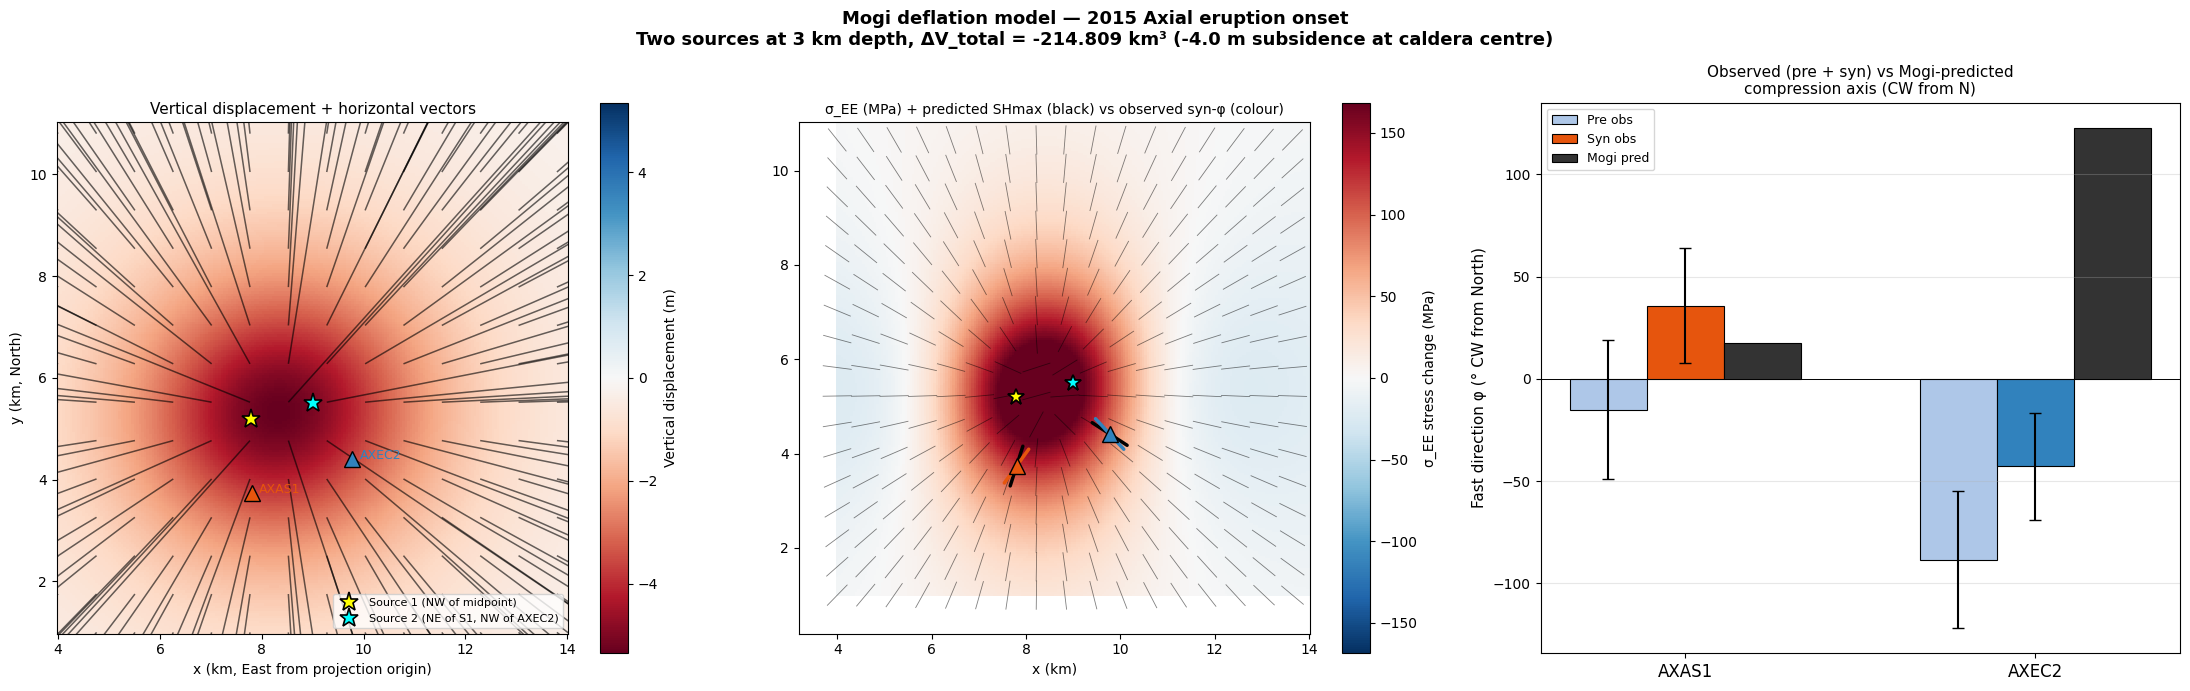

In [9]:
# ── Figure: displacement field, stress map, and φ comparison ─────────────

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    f'Mogi deflation model — 2015 Axial eruption onset\n'
    f'Two sources at 3 km depth, ΔV_total = {dV_total/1e6:.3f} km³ '
    f'({SUBSIDENCE_M:.1f} m subsidence at caldera centre)',
    fontsize=13, fontweight='bold')

sta_colors = {'AXAS1': '#e6550d', 'AXEC2': '#3182bd'}

# ── Panel 1: Vertical displacement map ───────────────────────────────────
ax = axes[0]
lim = max(abs(Uz.min()), abs(Uz.max()))
im  = ax.pcolormesh(x_grid_km, y_grid_km, Uz,
                    cmap='RdBu', vmin=-lim, vmax=lim, shading='auto')
plt.colorbar(im, ax=ax, label='Vertical displacement (m)')

# Horizontal displacement arrows (subsampled)
step = 15
ax.quiver(x_grid_km[::step], y_grid_km[::step],
          Ux[::step, ::step], Uy[::step, ::step],
          scale=0.3, width=0.003, color='k', alpha=0.6)

ax.plot(X1_KM, Y1_KM, '*', color='yellow', ms=14, mec='k', mew=1.2, zorder=5, label='Source 1 (NW of midpoint)')
ax.plot(X2_KM, Y2_KM, '*', color='cyan',   ms=14, mec='k', mew=1.2, zorder=5, label='Source 2 (NE of S1, NW of AXEC2)')
for sta, c in sta_colors.items():
    ax.plot(sta_info[sta]['x_km'], sta_info[sta]['y_km'],
            '^', color=c, ms=12, mec='k', zorder=6)
    ax.text(sta_info[sta]['x_km'] + 0.15, sta_info[sta]['y_km'], sta, fontsize=9, color=c)
ax.set_xlabel('x (km, East from projection origin)', fontsize=10)
ax.set_ylabel('y (km, North)', fontsize=10)
ax.set_title('Vertical displacement + horizontal vectors', fontsize=11)
ax.legend(fontsize=8, loc='lower right')
ax.set_aspect('equal')

# ── Panel 2: σ_EE stress and predicted SHmax directions ──────────────────
ax = axes[1]
lim2 = np.percentile(np.abs(sigma_EE_MPa), 97)
im2  = ax.pcolormesh(x_grid_km, y_grid_km, sigma_EE_MPa,
                     cmap='RdBu_r', vmin=-lim2, vmax=lim2, shading='auto')
plt.colorbar(im2, ax=ax, label='σ_EE stress change (MPa)')

# SHmax sticks (subsampled)
step2 = 12
for i in range(0, Xg.shape[0], step2):
    for j in range(0, Xg.shape[1], step2):
        az  = phi_pred_grid[i, j]
        az_rad = np.deg2rad(az)
        cx  = x_grid_km[j]
        cy  = y_grid_km[i]
        dx  = 0.3 * np.sin(az_rad)
        dy  = 0.3 * np.cos(az_rad)
        ax.plot([cx - dx, cx + dx], [cy - dy, cy + dy],
                '-', color='k', lw=0.6, alpha=0.5)

# Overlay observed fast directions at stations
for sta, c in sta_colors.items():
    ax.plot(X1_KM, Y1_KM, '*', color='yellow', ms=12, mec='k', mew=1.2, zorder=5)
    ax.plot(X2_KM, Y2_KM, '*', color='cyan',   ms=12, mec='k', mew=1.2, zorder=5)
    sx  = sta_info[sta]['x_km']
    sy  = sta_info[sta]['y_km']
    ax.plot(sx, sy, '^', color=c, ms=12, mec='k', zorder=6)
    # Predicted φ (black stick)
    pred_az  = results[sta]['phi_pred_CW_N']
    prad     = np.deg2rad(pred_az)
    ax.annotate('', xy=(sx + 0.5*np.sin(prad),  sy + 0.5*np.cos(prad)),
                    xytext=(sx - 0.5*np.sin(prad), sy - 0.5*np.cos(prad)),
                arrowprops=dict(arrowstyle='-', color='k', lw=2.5))
    # Observed syn φ (coloured stick)
    syn_az   = obs[sta]['Syn-eruption']['mean']
    srad     = np.deg2rad(syn_az)
    ax.annotate('', xy=(sx + 0.5*np.sin(srad),  sy + 0.5*np.cos(srad)),
                    xytext=(sx - 0.5*np.sin(srad), sy - 0.5*np.cos(srad)),
                arrowprops=dict(arrowstyle='-', color=c, lw=2.5))

ax.set_xlabel('x (km)', fontsize=10)
ax.set_title('σ_EE (MPa) + predicted SHmax (black) vs observed syn-φ (colour)', fontsize=10)
ax.set_aspect('equal')

# ── Panel 3: Bar chart — predicted vs observed φ ─────────────────────────
ax = axes[2]
stations_plot = ['AXAS1', 'AXEC2']
x_pos = np.arange(len(stations_plot))
w     = 0.22

for k, sta in enumerate(stations_plot):
    c = sta_colors[sta]
    pre = obs[sta]['Pre-eruption']['mean']
    syn = obs[sta]['Syn-eruption']['mean']
    std_pre = obs[sta]['Pre-eruption']['std']
    std_syn = obs[sta]['Syn-eruption']['std']
    pred = results[sta]['phi_pred_CW_N']

    ax.bar(x_pos[k] - w,    pre,  w, color='#aec7e8', edgecolor='k', lw=0.8, label='Pre obs' if k==0 else '')
    ax.bar(x_pos[k],        syn,  w, color=c,          edgecolor='k', lw=0.8, label='Syn obs' if k==0 else '')
    ax.bar(x_pos[k] + w,    pred, w, color='#333333',  edgecolor='k', lw=0.8, label='Mogi pred' if k==0 else '')
    ax.errorbar(x_pos[k] - w, pre, yerr=std_pre, fmt='none', color='k', capsize=4)
    ax.errorbar(x_pos[k],     syn, yerr=std_syn, fmt='none', color='k', capsize=4)

ax.set_xticks(x_pos)
ax.set_xticklabels(stations_plot, fontsize=12)
ax.set_ylabel('Fast direction φ (° CW from North)', fontsize=11)
ax.set_title('Observed (pre + syn) vs Mogi-predicted\ncompression axis (CW from N)', fontsize=11)
ax.legend(fontsize=9)
ax.axhline(0, color='k', lw=0.7)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/mogi_stress_2015_eruption.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

In [10]:
# ── Summary: stress change magnitudes at station locations ────────────────

print("\n" + "="*70)
print("  Mogi-predicted stress change at eruption onset")
print(f"  (ΔV_total = {dV_total/1e6:.3f} km³, two sources at {DEPTH_M/1e3:.1f} km depth)")
print("="*70)
for sta in ['AXAS1', 'AXEC2']:
    r   = results[sta]
    s   = r['stress'] / 1e6   # MPa
    D   = r['D_MPa']
    uz  = r['uz_m']
    phi = r['phi_pred_CW_N']
    syn_obs = obs[sta]['Syn-eruption']['mean']
    pre_obs = obs[sta]['Pre-eruption']['mean']

    print(f"\n  {sta}")
    print(f"    Predicted vertical displacement : {uz*100:+.1f} cm")
    print(f"    Stress change σ_EE (E-E)        : {s[0,0]:+.4f} MPa")
    print(f"    Stress change σ_NN (N-N)        : {s[1,1]:+.4f} MPa")
    print(f"    Stress change σ_EN (shear)      : {s[0,1]:+.4f} MPa")
    print(f"    σ1 (max principal)              : {r['eigvals_MPa'][0]:+.4f} MPa")
    print(f"    σ2 (min principal)              : {r['eigvals_MPa'][1]:+.4f} MPa")
    print(f"    ΔD (differential stress change) : {D:+.4f} MPa")
    print(f"    Predicted compression axis φ    : {phi:.1f}° CW from N")
    print(f"    Observed SWS φ (pre-eruption)   : {pre_obs:+.1f}° CW from N")
    print(f"    Observed SWS φ (syn-eruption)   : {syn_obs:+.1f}° CW from N")

print("\n  Note: stress values are the CHANGE from the Mogi deflation only.")
print("  The background (tectonic + far-field) stress is not included.")
print("  Compare predicted φ with syn-eruption obs for consistency.")


  Mogi-predicted stress change at eruption onset
  (ΔV_total = -214.809 km³, two sources at 3.0 km depth)

  AXAS1
    Predicted vertical displacement : -366.5 cm
    Stress change σ_EE (E-E)        : +121.9989 MPa
    Stress change σ_NN (N-N)        : +81.7337 MPa
    Stress change σ_EN (shear)      : -14.2951 MPa
    σ1 (max principal)              : +126.5579 MPa
    σ2 (min principal)              : +77.1747 MPa
    ΔD (differential stress change) : +49.3832 MPa
    Predicted compression axis φ    : 17.7° CW from N
    Observed SWS φ (pre-eruption)   : -15.1° CW from N
    Observed SWS φ (syn-eruption)   : +35.9° CW from N

  AXEC2
    Predicted vertical displacement : -366.1 cm
    Stress change σ_EE (E-E)        : +92.2123 MPa
    Stress change σ_NN (N-N)        : +112.7564 MPa
    Stress change σ_EN (shear)      : +22.9792 MPa
    σ1 (max principal)              : +127.6550 MPa
    σ2 (min principal)              : +77.3137 MPa
    ΔD (differential stress change) : +50.3412 MPa

Sphere summary:
  S1 (deep)       z0=3.33 km  R=0.43 km  |dV| = 3.776e+05 m³  (0.37759 km³)
  S2 (shallow)    z0=1.25 km  R=0.20 km  |dV| = 3.799e+04 m³  (0.03799 km³)
  AXAS1: x=7.80 km, y=3.74 km
  AXEC2: x=9.77 km, y=4.42 km
  AXEC1: x=9.32 km, y=5.52 km
  AXEC3: x=9.41 km, y=4.02 km
  AXAS2: x=6.65 km, y=3.76 km

obs5 summary (5 stations):
  Station      Pre φ    Pre σ     Syn φ    Syn σ  Δφ
  ───────────────────────────────────────────────────────
  AXAS1        -15.1     34.0     +35.9     28.0  +51.0°
  AXEC2        -88.4     33.6     -42.8     26.1  +45.6°
  AXEC1        -73.9     41.6     +75.4     33.8  -30.7°
  AXEC3        -72.4     38.3     -15.9     30.1  +56.4°
  AXAS2        -40.7     35.4     -55.4     39.7  -14.6°

  PART A — Deflation stress at eruption onset  (dP = -0.05 GPa)
  Station     Pre phi    Syn phi   Pred phi   Syn-Pred   D (MPa)
  ──────────────────────────────────────────────────────────────────────
  AXAS1         -15.1      +35.9     +171.0        +44.

  Observed phi by epoch:
  Epoch                    AXAS1             AXEC2
  Pre-erupt         -15.1°±34.0°      -88.4°±33.6°
  Syn-erupt         +35.9°±28.0°      -42.8°±26.1°
  2015-post         +24.0°±33.5°      -31.6°±36.1°
  2016              +21.0°±22.6°      -22.2°±23.5°
  2017              +20.6°±27.1°      -15.7°±31.3°
  2018               -0.4°±26.8°      -56.3°±42.6°
  2019               -4.6°±28.0°      -62.2°±38.8°
  2020               +2.9°±29.0°      -73.5°±33.2°
  2021              -22.8°±25.4°      -69.5°±33.1°


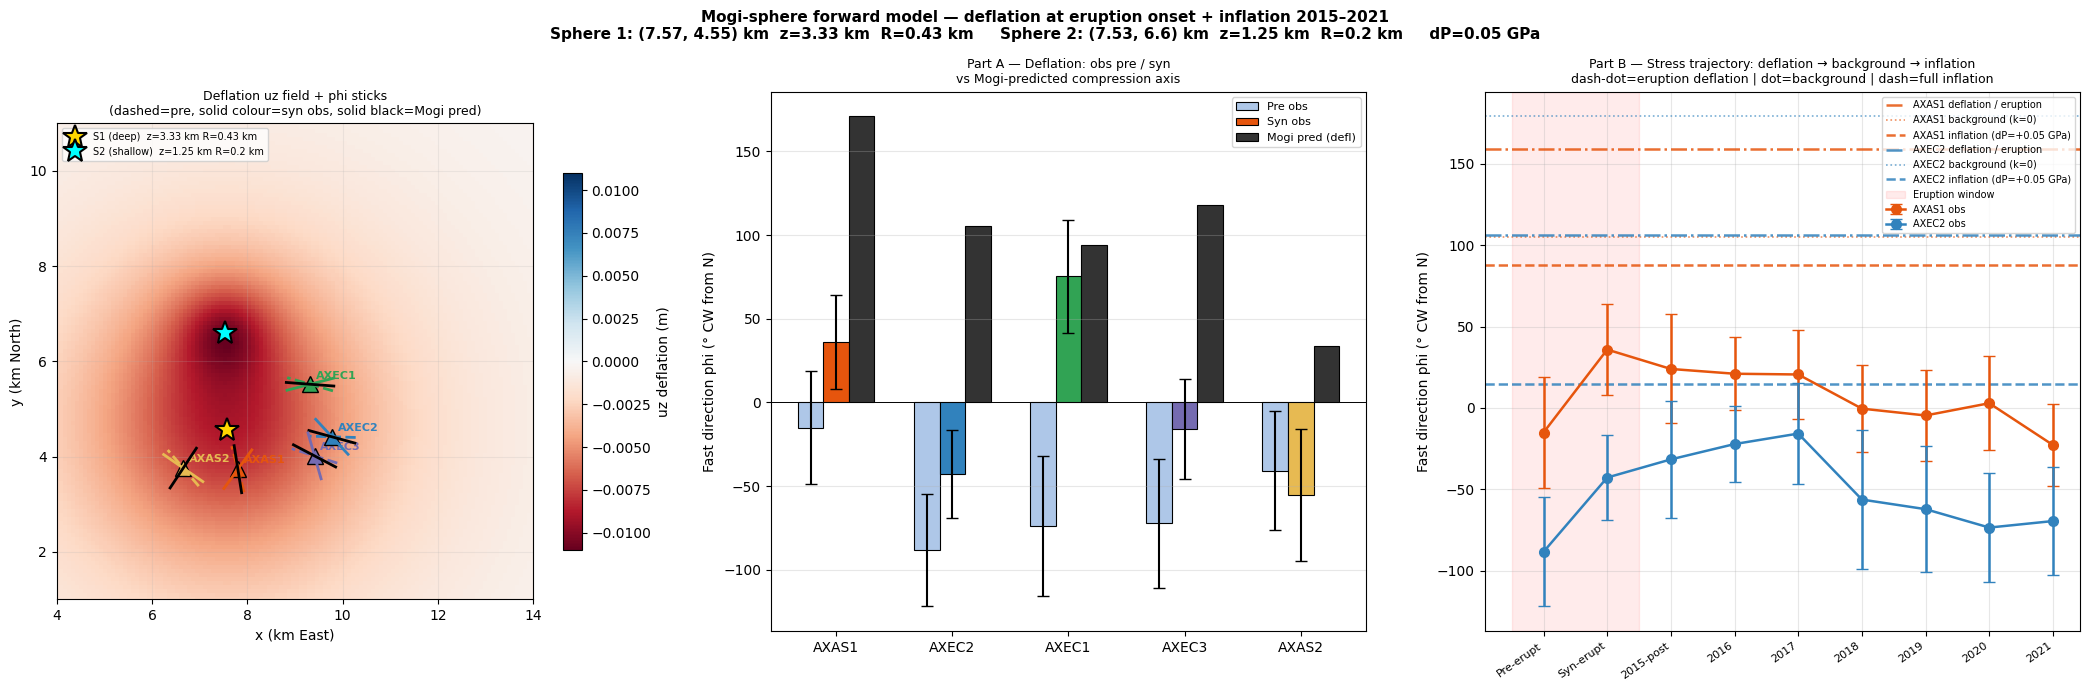

Saved: results/mogi_sphere_forward_model.png


In [11]:
# ── Forward model: stress from given Mogi-like spheres ───────────────────
#
# Sphere parameters (local km, origin = 130.1°W / 45.9°N):
#   Sphere 1  x0=7.57, y0=4.55, z0=3.33 km, R=0.43 km
#   Sphere 2  x0=7.53, y0=6.60, z0=1.25 km, R=0.20 km
#
# Volume change from a pressurised sphere (McTigue 1987 equivalence):
#   dV = π R³ dP / μ
# Deflation at eruption onset → dP < 0 → dV < 0.
# Inflation post-eruption    → dP > 0 → dV > 0.

# ── Sphere definitions ────────────────────────────────────────────────────
spheres_km = [
    {'label': 'S1 (deep)',    'x0': 7.57, 'y0': 4.55, 'z0': 3.33, 'R': 0.43},
    {'label': 'S2 (shallow)', 'x0': 7.53, 'y0': 6.60, 'z0': 1.25, 'R': 0.20},
]

dP_GPa  = 0.05           # GPa — reference pressure used for dV_unit
dP_Pa   = dP_GPa * 1e9  # Pa

for sp in spheres_km:
    sp['x0_m'] = sp['x0'] * 1e3
    sp['y0_m'] = sp['y0'] * 1e3
    sp['z0_m'] = sp['z0'] * 1e3
    sp['R_m']  = sp['R']  * 1e3
    sp['dV_unit'] = np.pi * sp['R_m']**3 * dP_Pa / mu   # m³ for dP = dP_Pa

print("Sphere summary:")
for sp in spheres_km:
    print(f"  {sp['label']:14s}  z0={sp['z0']:.2f} km  R={sp['R']:.2f} km  "
          f"|dV| = {abs(sp['dV_unit']):.3e} m³  ({abs(sp['dV_unit'])/1e6:.5f} km³)")

# ── All 5 station coordinates ─────────────────────────────────────────────
sws_stations_5 = ['AXAS1', 'AXEC2', 'AXEC1', 'AXEC3', 'AXAS2']

sta_coords_5 = {
    'AXAS1': {'lon': -129.999289, 'lat': 45.93356},
    'AXEC2': {'lon': -129.9738,   'lat': 45.93967},
    'AXEC1': {'lon': -129.9797,   'lat': 45.94958},
    'AXEC3': {'lon': -129.9785,   'lat': 45.93607},
    'AXAS2': {'lon': -130.0141,   'lat': 45.93377},
}

all_sta5 = {}
for sta, info in sta_coords_5.items():
    x, y = ll2xy(info['lon'], info['lat'])
    all_sta5[sta] = {**info, 'x_km': x, 'y_km': y}
    print(f"  {sta}: x={x:.2f} km, y={y:.2f} km")

# ── Load SWS data for all 5 stations → obs5 ──────────────────────────────
mldd_sta   = ['AXAS1', 'AXEC2']
batch_sta  = ['AXEC1', 'AXEC3', 'AXAS2']

batch_files = {
    'AXEC1': '../results/splitting_results_axec1_batch_apr_14_jun_01_combined_cleaned.csv',
    'AXEC3': '../results/splitting_results_axec3_batch_apr_14_jun_01_combined_cleaned.csv',
    'AXAS2': '../results/splitting_results_axas2_batch_apr_14_jun_01_combined_cleaned.csv',
}

SYN_START       = '2015-04-24'
SYN_END         = '2015-05-19'
PRE_START_BATCH = '2015-04-14'   # batch files only cover Apr–Jun

obs5 = {}

# AXAS1 and AXEC2: pull from obs dict already computed above
for sta in mldd_sta:
    obs5[sta] = {
        'pre_mean': obs[sta]['Pre-eruption']['mean'],
        'pre_std':  obs[sta]['Pre-eruption']['std'],
        'syn_mean': obs[sta]['Syn-eruption']['mean'],
        'syn_std':  obs[sta]['Syn-eruption']['std'],
    }

# AXEC1, AXEC3, AXAS2: from batch CSV files
for sta in batch_sta:
    df = pd.read_csv(batch_files[sta])
    df['event_datetime'] = pd.to_datetime(df['event_datetime'])
    df = df[(df['phi_error'] < 20) & (df['snr_horizontal'] > 3)].copy()

    pre_phi = df.loc[(df['event_datetime'] >= PRE_START_BATCH) &
                     (df['event_datetime'] <  SYN_START), 'phi'].dropna().values
    syn_phi = df.loc[(df['event_datetime'] >= SYN_START) &
                     (df['event_datetime'] <  SYN_END),   'phi'].dropna().values

    obs5[sta] = {
        'pre_mean': axial_mean_CW_N(pre_phi) if len(pre_phi) > 3 else np.nan,
        'pre_std':  axial_std(pre_phi)        if len(pre_phi) > 3 else np.nan,
        'syn_mean': axial_mean_CW_N(syn_phi)  if len(syn_phi) > 3 else np.nan,
        'syn_std':  axial_std(syn_phi)         if len(syn_phi) > 3 else np.nan,
    }

print("\nobs5 summary (5 stations):")
print(f"  {'Station':<8}  {'Pre φ':>8}  {'Pre σ':>7}  {'Syn φ':>8}  {'Syn σ':>7}  Δφ")
print("  " + "─" * 55)
for sta in sws_stations_5:
    r = obs5[sta]
    dphi = (r['syn_mean'] - r['pre_mean'] + 90) % 180 - 90 if not np.isnan(r['syn_mean']) else np.nan
    print(f"  {sta:<8}  {r['pre_mean']:>+8.1f}  {r['pre_std']:>7.1f}  "
          f"{r['syn_mean']:>+8.1f}  {r['syn_std']:>7.1f}  {dphi:>+.1f}°")

# ── Stress at station function ────────────────────────────────────────────
sta_colors5 = {
    'AXAS1': '#e6550d', 'AXEC2': '#3182bd',
    'AXEC1': '#31a354', 'AXEC3': '#756bb1', 'AXAS2': '#e7ba52',
}

def stress_at_station(sta, sign=+1):
    """
    Combined stress tensor at a station from both spheres.
    sign = -1: deflation (eruption)   sign = +1: inflation (post-eruption)
    Returns: stress tensor (Pa), SHmax azimuth (°), differential stress (MPa).
    """
    xs  = all_sta5[sta]['x_km'] * 1e3
    ys  = all_sta5[sta]['y_km'] * 1e3
    eps = np.zeros((2, 2))
    for sp in spheres_km:
        dV = sign * sp['dV_unit']
        eps += mogi_strain_2d(xs, ys, sp['x0_m'], sp['y0_m'], sp['z0_m'], dV, nu)
    stress   = strain2stress(eps, nu, mu)
    phi, eig = shmax_azimuth_deg(stress)
    D        = (eig[0] - eig[1]) / 1e6
    return stress, phi, D

# ─────────────────────────────────────────────────────────────────────────
# PART A — Eruption deflation: predicted vs observed SWS φ
# ─────────────────────────────────────────────────────────────────────────
print()
print("=" * 72)
print(f"  PART A — Deflation stress at eruption onset  (dP = -{dP_GPa:.2f} GPa)")
print("=" * 72)
print(f"  {'Station':<8}  {'Pre phi':>9}  {'Syn phi':>9}  {'Pred phi':>9}  "
      f"{'Syn-Pred':>9}  {'D (MPa)':>8}")
print("  " + "─" * 70)

defl_results = {}
for sta in sws_stations_5:
    stress, phi_pred, D = stress_at_station(sta, sign=-1)
    pre  = obs5[sta]['pre_mean']
    syn  = obs5[sta]['syn_mean']
    diff = (syn - phi_pred + 90) % 180 - 90
    defl_results[sta] = {'phi_pred': phi_pred, 'D_MPa': D, 'stress': stress}
    print(f"  {sta:<8}  {pre:>+9.1f}  {syn:>+9.1f}  {phi_pred:>+9.1f}  "
          f"  {diff:>+9.1f}  {D:>8.4f}")

# ─────────────────────────────────────────────────────────────────────────
# PART B — Post-eruption inflation forward model (AXAS1, AXEC2 only)
# ─────────────────────────────────────────────────────────────────────────
print()
print("=" * 72)
print("  PART B — Inflation forward model (AXAS1 + AXEC2, 2015–2021)")
print("=" * 72)

mldd_files = {
    'AXAS1': '../results/splitting_results_mldd_2015_2021_axas1.csv',
    'AXEC2': '../results/axial-mldd-2015-2021-axec2.csv',
}
year_epochs = {
    'Pre-erupt': ('2015-01-01', '2015-04-24'),
    'Syn-erupt': ('2015-04-24', '2015-05-19'),
    '2015-post': ('2015-05-19', '2016-01-01'),
    '2016':      ('2016-01-01', '2017-01-01'),
    '2017':      ('2017-01-01', '2018-01-01'),
    '2018':      ('2018-01-01', '2019-01-01'),
    '2019':      ('2019-01-01', '2020-01-01'),
    '2020':      ('2020-01-01', '2021-01-01'),
    '2021':      ('2021-01-01', '2022-01-01'),
}

ts_obs = {}
for sta, fpath in mldd_files.items():
    df = pd.read_csv(fpath)
    df['event_datetime'] = pd.to_datetime(df['event_datetime'])
    df = df[(df['phi_error'] < 20) & (df['snr_horizontal'] > 3)].copy()
    ts_obs[sta] = {}
    for epoch, (t0, t1) in year_epochs.items():
        phi = df.loc[(df['event_datetime'] >= t0) & (df['event_datetime'] < t1),
                     'phi'].dropna().values
        if len(phi) > 5:
            ts_obs[sta][epoch] = {'mean': axial_mean_CW_N(phi),
                                  'std':  axial_std(phi), 'n': len(phi)}
        else:
            ts_obs[sta][epoch] = {'mean': np.nan, 'std': np.nan, 'n': len(phi)}

print("  Observed phi by epoch:")
print(f"  {'Epoch':<12}", end='')
for sta in ['AXAS1', 'AXEC2']:
    print(f"  {sta:>16}", end='')
print()
for epoch in year_epochs:
    print(f"  {epoch:<12}", end='')
    for sta in ['AXAS1', 'AXEC2']:
        v = ts_obs[sta][epoch]
        s = f"{v['mean']:+.1f}°±{v['std']:.1f}°" if not np.isnan(v['mean']) else "  —"
        print(f"  {s:>16}", end='')
    print()

# Inflation sweep
infl_sweep_k = np.linspace(-1, 1, 400)
infl_phi = {sta: [] for sta in ['AXAS1', 'AXEC2']}

for sta in ['AXAS1', 'AXEC2']:
    xs = all_sta5[sta]['x_km'] * 1e3
    ys = all_sta5[sta]['y_km'] * 1e3
    phi_pre  = ts_obs[sta]['Pre-erupt']['mean']
    phi_syn  = ts_obs[sta]['Syn-erupt']['mean']
    phi_defl = defl_results[sta]['phi_pred']
    D_Mogi   = abs(defl_results[sta]['D_MPa'])

    delta_phi_rad = np.deg2rad((phi_syn - phi_pre + 90) % 180 - 90)
    if abs(delta_phi_rad) > np.deg2rad(2):
        D_bg = D_Mogi / abs(np.tan(2 * delta_phi_rad))
    else:
        D_bg = 5 * D_Mogi

    phi_pre_rad = np.deg2rad(phi_pre)
    sigma_bg = D_bg * np.array([
        [-np.cos(2 * phi_pre_rad), -np.sin(2 * phi_pre_rad)],
        [-np.sin(2 * phi_pre_rad),  np.cos(2 * phi_pre_rad)]
    ])

    eps_infl = np.zeros((2, 2))
    for sp in spheres_km:
        eps_infl += mogi_strain_2d(xs, ys, sp['x0_m'], sp['y0_m'], sp['z0_m'],
                                   sp['dV_unit'], nu)
    sigma_infl_MPa = strain2stress(eps_infl, nu, mu) / 1e6

    for k in infl_sweep_k:
        total = sigma_bg + k * sigma_infl_MPa
        phi_k, _ = shmax_azimuth_deg(total)
        infl_phi[sta].append(phi_k)

# Figure
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(
    f'Mogi-sphere forward model — deflation at eruption onset + inflation 2015–2021\n'
    f'Sphere 1: ({spheres_km[0]["x0"]}, {spheres_km[0]["y0"]}) km  z={spheres_km[0]["z0"]} km  '
    f'R={spheres_km[0]["R"]} km     '
    f'Sphere 2: ({spheres_km[1]["x0"]}, {spheres_km[1]["y0"]}) km  z={spheres_km[1]["z0"]} km  '
    f'R={spheres_km[1]["R"]} km     dP={dP_GPa} GPa',
    fontsize=11, fontweight='bold')

ax = axes[0]
x_plot = np.linspace(4, 14, 120)
y_plot = np.linspace(1, 11, 120)
Xp, Yp = np.meshgrid(x_plot * 1e3, y_plot * 1e3)
Uz_defl = sum(mogi_uz(Xp, Yp, sp['x0_m'], sp['y0_m'], sp['z0_m'],
                       -sp['dV_unit'], nu) for sp in spheres_km)
lim = max(abs(Uz_defl.min()), abs(Uz_defl.max()))
im = ax.pcolormesh(x_plot, y_plot, Uz_defl, cmap='RdBu',
                   vmin=-lim, vmax=lim, shading='auto')
plt.colorbar(im, ax=ax, label='uz deflation (m)', shrink=0.7)

for i, sp in enumerate(spheres_km):
    ax.plot(sp['x0'], sp['y0'], '*', ms=18, mec='k', mew=1.5,
            color=['gold', 'cyan'][i], zorder=9,
            label=f"{sp['label']}  z={sp['z0']} km R={sp['R']} km")

for sta in sws_stations_5:
    sx, sy = all_sta5[sta]['x_km'], all_sta5[sta]['y_km']
    c = sta_colors5[sta]
    ax.plot(sx, sy, '^', color=c, ms=11, mec='k', mew=1, zorder=8)
    ax.text(sx + 0.12, sy + 0.12, sta, fontsize=8, color=c, fontweight='bold')
    for az, ls, col_flag in [(obs5[sta]['pre_mean'], '--', 'sta'),
                              (obs5[sta]['syn_mean'], '-',  'sta'),
                              (defl_results[sta]['phi_pred'], '-', 'black')]:
        if np.isnan(az):
            continue
        col = c if col_flag == 'sta' else 'k'
        rad = np.deg2rad(az)
        ax.plot([sx - 0.5*np.sin(rad), sx + 0.5*np.sin(rad)],
                [sy - 0.5*np.cos(rad), sy + 0.5*np.cos(rad)],
                ls, color=col, lw=2, zorder=10)

ax.set_xlabel('x (km East)', fontsize=10)
ax.set_ylabel('y (km North)', fontsize=10)
ax.set_title('Deflation uz field + phi sticks\n'
             '(dashed=pre, solid colour=syn obs, solid black=Mogi pred)', fontsize=9)
ax.legend(fontsize=7, loc='upper left')
ax.set_aspect('equal');  ax.set_xlim(4, 14);  ax.set_ylim(1, 11)
ax.grid(True, alpha=0.2)

ax = axes[1]
x_pos = np.arange(len(sws_stations_5))
w = 0.22
for k, sta in enumerate(sws_stations_5):
    c = sta_colors5[sta]
    pre  = obs5[sta]['pre_mean']
    syn  = obs5[sta]['syn_mean']
    pred = defl_results[sta]['phi_pred']
    std_pre = obs5[sta].get('pre_std', 0) or 0
    std_syn = obs5[sta].get('syn_std', 0) or 0
    ax.bar(x_pos[k] - w,   pre,  w, color='#aec7e8', edgecolor='k', lw=0.8,
           label='Pre obs' if k == 0 else '')
    ax.bar(x_pos[k],       syn,  w, color=c,          edgecolor='k', lw=0.8,
           label='Syn obs' if k == 0 else '')
    ax.bar(x_pos[k] + w,   pred, w, color='#333333',  edgecolor='k', lw=0.8,
           label='Mogi pred (defl)' if k == 0 else '')
    ax.errorbar(x_pos[k] - w, pre, yerr=std_pre, fmt='none', color='k', capsize=4)
    ax.errorbar(x_pos[k],     syn, yerr=std_syn, fmt='none', color='k', capsize=4)
ax.set_xticks(x_pos);  ax.set_xticklabels(sws_stations_5, fontsize=10)
ax.set_ylabel('Fast direction phi (° CW from N)', fontsize=10)
ax.set_title('Part A — Deflation: obs pre / syn\nvs Mogi-predicted compression axis', fontsize=9)
ax.legend(fontsize=8);  ax.axhline(0, color='k', lw=0.7);  ax.grid(True, axis='y', alpha=0.3)

ax = axes[2]
epoch_labels = list(year_epochs.keys())
x_epochs = np.arange(len(epoch_labels))

for sta in ['AXAS1', 'AXEC2']:
    c = sta_colors5[sta]
    means = [ts_obs[sta][ep]['mean'] for ep in epoch_labels]
    stds  = [ts_obs[sta][ep]['std']  for ep in epoch_labels]
    ax.errorbar(x_epochs, means, yerr=stds, fmt='o-', color=c, lw=1.8,
                capsize=4, ms=7, label=f'{sta} obs', zorder=6)

    phi_defl = infl_phi[sta][0]
    phi_bg   = infl_phi[sta][len(infl_sweep_k)//2]
    phi_infl = infl_phi[sta][-1]
    ax.axhline(phi_defl, color=c, lw=1.8, ls='-.', alpha=0.85,
               label=f'{sta} deflation / eruption')
    ax.axhline(phi_bg,   color=c, lw=1.2, ls=':',  alpha=0.65,
               label=f'{sta} background (k=0)')
    ax.axhline(phi_infl, color=c, lw=1.8, ls='--', alpha=0.85,
               label=f'{sta} inflation (dP=+{dP_GPa} GPa)')

ax.axvspan(-0.5, 1.5, alpha=0.08, color='red', label='Eruption window')
ax.set_xticks(x_epochs);  ax.set_xticklabels(epoch_labels, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Fast direction phi (° CW from N)', fontsize=10)
ax.set_title('Part B — Stress trajectory: deflation → background → inflation\n'
             'dash-dot=eruption deflation | dot=background | dash=full inflation', fontsize=9)
ax.legend(fontsize=7, loc='best');  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/mogi_sphere_forward_model.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: results/mogi_sphere_forward_model.png')


In [125]:
# ── Cell 12: Stress magnitude inversion from observed Δφ ─────────────────
#
# The Mogi spheres fix the GEOMETRY (shape) of the stress perturbation at
# each station — i.e., the ratio of stress components.  The absolute
# magnitude is set by the source pressure change dP.
#
# Here we solve for dP [MPa] and the background differential stress D_bg [MPa]
# simultaneously by fitting the predicted SHmax azimuth to the observed
# syn-eruption fast directions at all 5 stations (overdetermined: 5 obs, 2 unknowns).
#
# Model:
#   σ_total(sta) = D_bg · B_unit(φ_bg)  −  dP · U_Mogi(sta)
#                 [background deviatoric]  [eruption deflation]
#
#   φ_pred(sta) = SHmax_azimuth( σ_total(sta) )
#   residual    = φ_pred(sta) − φ_syn_obs(sta)   [wrapped to ±90°]
#
# B_unit  = unit deviatoric tensor with compression axis at the mean pre-φ
# U_Mogi  = unit stress tensor at each station (Pa stress per Pa source pressure)

from scipy.optimize import least_squares as scipy_lsq

# ── 1.  Unit Mogi stress tensors (Pa stress per Pa source ΔP) ─────────────
# dV_unit was computed for dP = dP_Pa = dP_GPa * 1e9 Pa, so divide out.

U_Mogi = {}
for sta in sws_stations_5:
    xs  = all_sta5[sta]['x_km'] * 1e3
    ys  = all_sta5[sta]['y_km'] * 1e3
    eps = np.zeros((2, 2))
    for sp in spheres_km:
        eps += mogi_strain_2d(xs, ys, sp['x0_m'], sp['y0_m'], sp['z0_m'],
                              sp['dV_unit'], nu)
    U_Mogi[sta] = strain2stress(eps, nu, mu) / dP_Pa   # Pa / Pa  (dimensionless)

# ── 2.  Background stress direction ───────────────────────────────────────
# Circular mean of the pre-eruption SHmax at all 5 stations.

phi_pre_all = np.array([obs5[sta]['pre_mean'] for sta in sws_stations_5])
phi_bg_deg  = axial_mean_CW_N(phi_pre_all)
phi_bg_rad  = np.deg2rad(phi_bg_deg)

# Deviatoric tensor with SHmax (compression) along phi_bg:
B_unit = np.array([
    [-np.cos(2 * phi_bg_rad), -np.sin(2 * phi_bg_rad)],
    [-np.sin(2 * phi_bg_rad),  np.cos(2 * phi_bg_rad)]
])

print(f"Background SHmax direction (circular mean of pre-φ): {phi_bg_deg:.1f}° CW from N")
print(f"Individual pre-φ: " +
      ", ".join(f"{sta}={obs5[sta]['pre_mean']:+.1f}°" for sta in sws_stations_5))

# ── 3.  Forward model and residual function ───────────────────────────────

def phi_pred_defl(dP_MPa, D_bg_MPa, sta):
    """
    Predicted SHmax azimuth for deflation scenario.
    dP_MPa   > 0  = magnitude of source pressure DROP (deflation).
    D_bg_MPa > 0  = background differential stress magnitude.
    """
    sigma = D_bg_MPa * 1e6 * B_unit - dP_MPa * 1e6 * U_Mogi[sta]
    az, _ = shmax_azimuth_deg(sigma)
    return az

def residuals_defl(params):
    dP, Dbg = params
    return [((phi_pred_defl(dP, Dbg, sta) - obs5[sta]['syn_mean']) + 90) % 180 - 90
            for sta in sws_stations_5]

# ── 4.  Least-squares solve ───────────────────────────────────────────────
fit = scipy_lsq(residuals_defl, x0=[50.0, 300.0],
                bounds=([0.1, 1.0], [5000.0, 50000.0]))
dP_opt, D_bg_opt = fit.x
rms_deg = np.sqrt(np.mean(np.array(fit.fun) ** 2))

# ── 5.  Report results ────────────────────────────────────────────────────
print()
print("=" * 70)
print("  STRESS MAGNITUDE FROM OBSERVED Δφ  (5-station least-squares fit)")
print("=" * 70)
print(f"  Best-fit eruption pressure drop : dP   = {dP_opt:.1f} MPa")
print(f"  Best-fit background diff. stress: D_bg = {D_bg_opt:.1f} MPa")
print(f"  RMS azimuth residual            : {rms_deg:.1f}°")
print()

hdr = (f"  {'Station':<7}  {'Pre φ':>7}  {'Syn φ':>7}  {'Pred φ':>8}"
       f"  {'Resid':>7}  {'ΔD_Mogi (MPa)':>14}")
print(hdr)
print("  " + "─" * (len(hdr) - 2))

for sta in sws_stations_5:
    pre   = obs5[sta]['pre_mean']
    syn   = obs5[sta]['syn_mean']
    pred  = phi_pred_defl(dP_opt, D_bg_opt, sta)
    resid = ((pred - syn) + 90) % 180 - 90
    # Differential stress from Mogi perturbation at this station
    s_mogi  = dP_opt * 1e6 * U_Mogi[sta]           # Pa
    evals   = np.sort(np.linalg.eigvalsh(s_mogi))  # ascending
    D_mogi_MPa = (evals[-1] - evals[0]) / 1e6
    print(f"  {sta:<7}  {pre:>+7.1f}  {syn:>+7.1f}  {pred:>+8.1f}"
          f"  {resid:>+7.1f}°  {D_mogi_MPa:>14.4f}")

# ── 6.  Implied volume changes ────────────────────────────────────────────
print()
print(f"  Implied eruption volume loss (|ΔV| = π R³ dP / μ):")
dV_total_opt = 0.0
for sp in spheres_km:
    dV_imp = np.pi * sp['R_m'] ** 3 * dP_opt * 1e6 / mu
    dV_total_opt += dV_imp
    print(f"    {sp['label']:15s}: |ΔV| = {abs(dV_imp) / 1e6:.5f} km³")
print(f"    {'Total':15s}: |ΔV| = {abs(dV_total_opt) / 1e6:.5f} km³")

# ── 7.  Stress ratio: perturbation / background ───────────────────────────
print()
print(f"  Stress ratio at each station  (ΔD_Mogi / D_bg):")
for sta in sws_stations_5:
    s_mogi = dP_opt * 1e6 * U_Mogi[sta]
    evals  = np.sort(np.linalg.eigvalsh(s_mogi))
    D_m    = (evals[-1] - evals[0]) / 1e6
    ratio  = D_m / D_bg_opt
    print(f"    {sta:<7}: ΔD_Mogi = {D_m:.4f} MPa   ratio = {ratio:.4f}")


Background SHmax direction (circular mean of pre-φ): -60.9° CW from N
Individual pre-φ: AXAS1=-15.1°, AXEC2=-88.4°, AXEC1=-73.9°, AXEC3=-72.4°, AXAS2=-40.7°

  STRESS MAGNITUDE FROM OBSERVED Δφ  (5-station least-squares fit)
  Best-fit eruption pressure drop : dP   = 4827.8 MPa
  Best-fit background diff. stress: D_bg = 6.0 MPa
  RMS azimuth residual            : 42.9°

  Station    Pre φ    Syn φ    Pred φ    Resid   ΔD_Mogi (MPa)
  ────────────────────────────────────────────────────────────
  AXAS1      -15.1    +35.9    +158.4    -57.5°          7.2099
  AXEC2      -88.4    -42.8    +131.2     -6.1°          9.6557
  AXEC1      -73.9    +75.4    +130.1    +54.7°          8.3381
  AXEC3      -72.4    -15.9    +136.7    -27.4°          9.2416
  AXAS2      -40.7    -55.4    +170.5    +45.9°          7.5739

  Implied eruption volume loss (|ΔV| = π R³ dP / μ):
    S1 (deep)      : |ΔV| = 36.45893 km³
    S2 (shallow)   : |ΔV| = 3.66850 km³
    Total          : |ΔV| = 40.12743 km³

  St